<a href="https://colab.research.google.com/github/rubenzito/localidadespalhmento/blob/main/Medidas_de_Localidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ideia do exemplo
Em vez de apresentar apenas fórmulas, vamos responder perguntas práticas, como:

- Qual é o **tamanho típico** de folhas e pétalas?
- Quando a **média** e a **mediana** contam histórias diferentes?
- Como usar **quantis** e **percentis** para definir faixas de tamanho padrão?
- Qual é o **tipo de flor mais frequente** no dataset?

In [8]:
# =========================
# 1. Importação e download da Base de Dados Iris
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# Download do iris.csv e salvar localmente
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.to_csv("iris.csv", index=False)

print("Base da Iris:", df.shape)
print("Arquivo salvo em: iris.csv")
display(df.head())

Base da Iris: (150, 5)
Arquivo salvo em: iris.csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1) Conhecendo as variáveis

Antes de calcular medidas de localidade, precisamos entender **o que cada variável mede**.
Nesta base (Iris), cada linha representa uma flor, e temos as seguintes variáveis:

- **sepal_length**: comprimento da folha
- **sepal_width**: largura da folha
- **petal_length**: comprimento da pétala
- **petal_width**: largura da pétala
- **species**: espécie da flor (setosa, versicolor, virginica)

As variáveis numéricas serão usadas para **média, mediana, quantis e percentis**.
A variável categórica `type` será usada para discutir a **moda**.

In [15]:
# ====================================
# 2. Ajustes das colunas para a análise
# ====================================

# Renomeando colunas para nomes mais curtos em português
df2 = df.rename(columns={
    "sepal_length": "comprimento_folha",
    "sepal_width": "largura_folha",
    "petal_length": "comprimento_petala",
    "petal_width": "largura_petala",
    "species": "type"
})

# Seleção de variáveis para o estudo
vars_numericas = ["comprimento_folha", "largura_folha", "comprimento_petala", "largura_petala"]

print("Tipos de dados:")
display(df2[vars_numericas + ["type"]].dtypes)

print("\nResumo estatístico inicial:")
display(df2[vars_numericas].describe().T)

Tipos de dados:


comprimento_folha     float64
largura_folha         float64
comprimento_petala    float64
largura_petala        float64
type                      str
dtype: object


Resumo estatístico inicial:


,count,mean,std,min,25%,50%,75%,max
comprimento_folha,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
largura_folha,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
comprimento_petala,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
largura_petala,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## 2) Média, mediana e moda: o que cada medida resume?

As três medidas procuram representar um **valor central**, mas não da mesma forma:

- **Média**: soma dos valores dividida pelo número de observações.  
  É muito útil, mas pode ser puxada por valores extremos.
- **Mediana**: valor central da distribuição ordenada.  
  É mais robusta a assimetrias e outliers.
- **Moda**: valor mais frequente.  
  É especialmente natural para variáveis categóricas, mas também pode ser calculada em variáveis discretas.

Em contexto industrial:

a média pode representar a condição média de operação;
a mediana pode representar a condição “mais típica” quando há assimetria;
a moda pode representar o regime/categoria mais frequente.

In [18]:
# ===========================================
# 3. Cálculo de média, mediana e moda
# ===========================================

def resumo_localidade(serie):
    moda = serie.mode()
    return pd.Series({
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": moda.iloc[0] if len(moda) > 0 else np.nan,
        "desvio_padrao": serie.std(),
        "assimetria": serie.skew()
    })

tabela_localidade = df2[vars_numericas].apply(resumo_localidade).T
display(tabela_localidade.round(3))

print("Moda da variável categórica 'type':")
display(df2["type"].mode())

print("\nDistribuição de frequência de 'type':")
display(df2["type"].value_counts())

,media,mediana,moda,desvio_padrao,assimetria
comprimento_folha,5.843,5.80,5.0,0.828,0.315
largura_folha,3.057,3.00,3.0,0.436,0.319
comprimento_petala,3.758,4.35,1.4,1.765,-0.275
largura_petala,1.199,1.30,0.2,0.762,-0.103


Moda da variável categórica 'type':


0        setosa
1    versicolor
2     virginica
Name: type, dtype: str


Distribuição de frequência de 'type':


type
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3) Como interpretar as diferenças entre média e mediana?

Quando **média** e **mediana** ficam muito próximas, a distribuição tende a ser relativamente simétrica.
Quando a **média** fica claramente acima ou abaixo da **mediana**, isso sugere assimetria.

No dataset Iris, duas variáveis são didaticamente interessantes para mostrar essas diferenças:

- **`comprimento_petala`**: apresenta variação significativa entre espécies;
- **`largura_folha`**: mostra comportamento mais concentrado.

Nos gráficos abaixo, traçaremos:
- linha da **média**,
- linha da **mediana**,
- linha da **moda**.

Assim, fica visível quando essas medidas praticamente coincidem e quando se afastam.

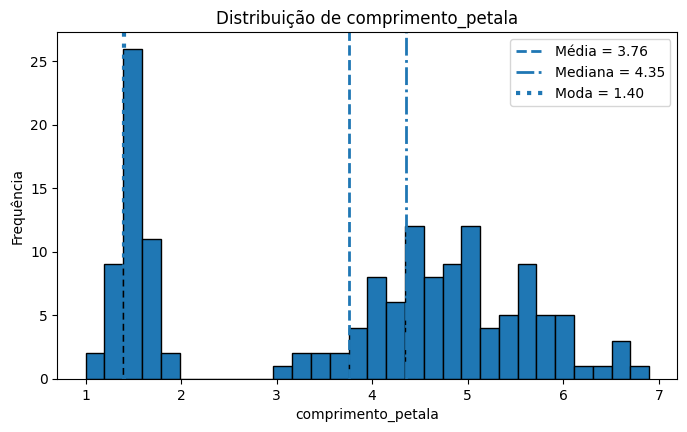

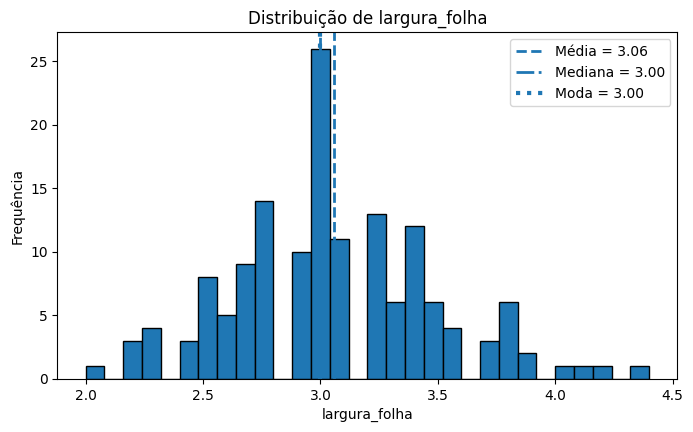

In [19]:
# ==================================================
# 4. Visualização: média vs mediana vs moda
# ==================================================

def plot_medidas_localidade(df, coluna, bins=30):
    s = df[coluna].dropna()
    media = s.mean()
    mediana = s.median()
    moda = s.mode().iloc[0]

    plt.figure(figsize=(8, 4.5))
    plt.hist(s, bins=bins, edgecolor="black")
    plt.axvline(media, linestyle="--", linewidth=2, label=f"Média = {media:.2f}")
    plt.axvline(mediana, linestyle="-.", linewidth=2, label=f"Mediana = {mediana:.2f}")
    plt.axvline(moda, linestyle=":", linewidth=3, label=f"Moda = {moda:.2f}")
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

plot_medidas_localidade(df2, "comprimento_petala")
plot_medidas_localidade(df2, "largura_folha")

## 4) Quantis e percentis: dividindo a operação em faixas

Os **quantis** e **percentis** não resumem apenas um centro: eles ajudam a **posicionar** observações dentro da distribuição.

### Quantis
- **Q1 (25%)**: 25% dos valores estão abaixo dele;
- **Q2 (50%)**: é a própria **mediana**;
- **Q3 (75%)**: 75% dos valores estão abaixo dele.

### Percentis
São a mesma ideia, mas com uma escala mais fina:
- **P10**: 10% abaixo;
- **P50**: igual à mediana;
- **P90**: 90% abaixo.

### Uso prático na indústria
Essas medidas são úteis para:
- definir **faixas operacionais normais**;
- identificar valores em **regime elevado** ou **regime crítico**;
- construir regras simples de monitoramento, por exemplo:
  - desgaste acima do **percentil 90**;
  - torque abaixo do **percentil 10**;
  - rotação entre o **Q1** e o **Q3**.

In [20]:
# ===========================================
# 5. Quantis e percentis
# ===========================================

quantis = df2[vars_numericas].quantile([0.25, 0.50, 0.75]).T
quantis.columns = ["Q1_25%", "Q2_50%_mediana", "Q3_75%"]

percentis = df2[vars_numericas].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentis.columns = ["P10", "P25", "P50", "P75", "P90"]

print("Quantis principais:")
display(quantis.round(3))

print("Percentis selecionados:")
display(percentis.round(3))

Quantis principais:


,Q1_25%,Q2_50%_mediana,Q3_75%
comprimento_folha,5.1,5.80,6.4
largura_folha,2.8,3.00,3.3
comprimento_petala,1.6,4.35,5.1
largura_petala,0.3,1.30,1.8


Percentis selecionados:


,P10,P25,P50,P75,P90
comprimento_folha,4.8,5.1,5.80,6.4,6.90
largura_folha,2.5,2.8,3.00,3.3,3.61
comprimento_petala,1.4,1.6,4.35,5.1,5.80
largura_petala,0.2,0.3,1.30,1.8,2.20


## 5) Exemplo prático: classificando tamanho das pétalas por percentis

Uma aplicação intuitiva de percentis é transformar uma variável contínua em **faixas de interpretação biológica**.

Aqui vamos usar `comprimento_petala`:

- até o **P25**: pétala pequena;
- entre **P25** e **P75**: pétala média/típica;
- acima do **P75**: pétala grande;
- acima do **P90**: pétala muito grande.

Essa ideia é útil porque não depende apenas de limites arbitrários; ela usa a própria distribuição observada na base.

In [21]:
# ======================================================
# 6. Criando faixas de tamanho com base em percentis
# ======================================================

p25 = df2["comprimento_petala"].quantile(0.25)
p75 = df2["comprimento_petala"].quantile(0.75)
p90 = df2["comprimento_petala"].quantile(0.90)

def classificar_petala(x):
    if x <= p25:
        return "pequena"
    elif x <= p75:
        return "media"
    elif x <= p90:
        return "grande"
    else:
        return "muito_grande"

df2["petala_class"] = df2["comprimento_petala"].apply(classificar_petala)

print("Limites usados:")
print(f"P25 = {p25:.2f}")
print(f"P75 = {p75:.2f}")
print(f"P90 = {p90:.2f}")

print("\nFrequência por faixa:")
display(df2["petala_class"].value_counts())

print("\nMédias das outras medidas por tamanho da pétala:")
display(df2.groupby("petala_class")[vars_numericas].mean().round(2))

Limites usados:
P25 = 1.60
P75 = 5.10
P90 = 5.80

Frequência por faixa:


petala_class
media           72
pequena         44
grande          21
muito_grande    13
Name: count, dtype: int64


Médias das outras medidas por tamanho da pétala:


,comprimento_folha,largura_folha,comprimento_petala,largura_petala
petala_class,,,,
grande,6.56,3.02,5.54,2.07
media,5.89,2.84,4.21,1.37
muito_grande,7.35,3.15,6.28,2.14
pequena,4.97,3.40,1.42,0.23


## 6) Moda em variável categórica: qual tipo de flor é o mais comum?

A **moda** é a medida de localidade mais natural para dados categóricos.

Na variável `type`, a moda responde:
> **Qual tipo de íris aparece com maior frequência no dataset?**

Esse tipo de informação é útil porque:
- ajuda a entender o **equilíbrio** entre as classes no dataset;
- contextualiza análises posteriores;
- evita interpretar médias numéricas sem considerar a distribuição dos tipos.

In [22]:
# ===========================================
# 7. Moda categórica e comparação por tipo
# ===========================================

moda_type = df2["type"].mode().iloc[0]
print("Moda de 'type':", moda_type)

freq_type = df2["type"].value_counts(normalize=True).mul(100).round(2).rename("percentual")
display(freq_type.to_frame())

print("\nMédias das variáveis numéricas por tipo de flor:")
display(df2.groupby("type")[vars_numericas].mean().round(2))

Moda de 'type': setosa


,percentual
type,
setosa,33.33
versicolor,33.33
virginica,33.33



Médias das variáveis numéricas por tipo de flor:


,comprimento_folha,largura_folha,comprimento_petala,largura_petala
type,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## 7) Síntese conceitual

Com este exemplo usando o dataset Iris, podemos resumir assim:

- **Média**: boa para resumir o nível médio das características, mas sensível a extremos;
- **Mediana**: melhor candidata a "valor típico" quando a distribuição é assimétrica;
- **Moda**: melhor resumo para categorias (como tipos de flor) e também útil em variáveis discretas;
- **Quantis**: particionam a distribuição em blocos;
- **Percentis**: refinam essa ideia e ajudam a construir faixas de classificação.

Em análise de dados, essas medidas são úteis não apenas para descrição, mas também para:
- exploração inicial dos dados,
- detecção de padrões e anomalias,
- criação de regras simples de classificação,
- entendimento da variabilidade natural dos dados.

In [24]:
# ===========================================
# 8. Tabela final-resumo
# ===========================================

resumo_final = pd.DataFrame({
    "media": df2[vars_numericas].mean(),
    "mediana": df2[vars_numericas].median(),
    "q1": df2[vars_numericas].quantile(0.25),
    "q3": df2[vars_numericas].quantile(0.75),
    "p10": df2[vars_numericas].quantile(0.10),
    "p90": df2[vars_numericas].quantile(0.90),
})

display(resumo_final.round(3))

moda = df2["type"].mode().iloc[0]
display(Markdown(
    f'''
**Conclusões rápidas do exemplo**
- A moda de `type` é **{moda}**.
- A mediana coincide com o percentil 50, como esperado.
- As faixas baseadas em percentis permitem traduzir medições contínuas em classes operacionais interpretáveis.
'''
))

,media,mediana,q1,q3,p10,p90
comprimento_folha,5.843,5.80,5.1,6.4,4.8,6.90
largura_folha,3.057,3.00,2.8,3.3,2.5,3.61
comprimento_petala,3.758,4.35,1.6,5.1,1.4,5.80
largura_petala,1.199,1.30,0.3,1.8,0.2,2.20



**Conclusões rápidas do exemplo**
- A moda de `type` é **setosa**.
- A mediana coincide com o percentil 50, como esperado.
- As faixas baseadas em percentis permitem traduzir medições contínuas em classes operacionais interpretáveis.
